<p> <center><img src="https://datascientest.fr/train/assets/logo_datascientest.png" style="height:200px"> </p>

<hr style="border-width:2px;border-color:#75DFC1">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Analyse exploratoire </h2></center>
<hr style="border-width:2px;border-color:#75DFC1">

## Chargement des données (CAMS / NASA)

Cette étape consiste à charger le fichier **"raw_2020_2024.csv"** contenant les données météorologiques et radiatives issues de **CAMS** (Copernicus Atmosphere Monitoring Service) et **NASA POWER**.  
Ces données sont généralement fournies par **point géographique (latitude/longitude)**, **par maille spatiale**, ou **agrégées par commune**, avec une résolution temporelle de **30 minutes**.

Les données CAMS/NASA comprennent notamment les variables suivantes :

- **`datetime_utc`** : horodatage en temps universel coordonné (UTC) correspondant à l'instant d'agrégation des données (résolution 30 minutes).
-  **`Périmètre`** : zone géographique associée aux données.
-  **`Consommation`** : consommation électrique totale du périmètre considéré sur l'intervalle de temps donné
-  **`Solaire`** : production électrique issue des installations photovoltaïques sur le périmètre considéré
-  **`Ech. physiques`** : flux nets d'électricité échangés avec les zones voisines (importations / exportations), exprimés en énergie sur l'intervalle temporel.
-  **`TCO Solaire (%)`** : taux de couverture de la production solaire.
-  **`TCH Solaire (%)`** : taux de charge de la production solaire.
- **`azimuth`** : azimut solaire (en degrés), indiquant la direction du soleil par rapport au nord (0–360° selon la convention).  
- **`altitude`** : altitude solaire (en degrés), représentant l'élévation du soleil au-dessus de l'horizon (valeurs négatives durant la nuit).  
- **`Temperature`** *(souvent `T2M`)* : température de l'air à 2 mètres du sol (en °C ou en K selon la source ; une vérification des unités est nécessaire).  
- **`GHI`** (*Global Horizontal Irradiance*) : irradiance globale reçue sur un plan horizontal (composantes directe et diffuse) exprimée en Wh/m².  
- **`BHI`** (*Beam Horizontal Irradiance*) : composante directe du rayonnement solaire projetée sur le plan horizontal (Wh/m²).  
- **`DHI`** (*Diffuse Horizontal Irradiance*) : composante diffuse du rayonnement solaire reçue sur un plan horizontal (Wh/m²).  
- **`BNI`** (*Beam Normal Irradiance*) : irradiance directe normale, reçue sur un plan perpendiculaire aux rayons solaires (Wh/m²).  
- **`Vitesse_Vent`** *(souvent `V2M`)* : vitesse du vent mesurée à 2 mètres du sol (m/s).  
- **`Nebulosite`** *(souvent `cloud_AMT`)* : nébulosité ou fraction de couverture nuageuse (exprimée selon les produits en fraction, pourcentage ou indice adimensionnel).  
- **`Humidite`** : humidité de l'air (généralement humidité relative en %, ou humidité spécifique selon la source).  
- **`Clear_sky_GHI`** : irradiance globale horizontale en conditions de ciel clair, utilisée comme référence théorique sans nuages (Wh/m²).  
- **`Clear_sky_BHI`** : composante directe horizontale en conditions de ciel clair (Wh/m²).  
- **`Clear_sky_DHI`** : composante diffuse horizontale en conditions de ciel clair (Wh/m²).  
- **`Clear_sky_BNI`** : irradiance directe normale en conditions de ciel clair (Wh/m²).  
- **`TOA`** (*Top Of Atmosphere*) : rayonnement solaire incident au sommet de l'atmosphère (Wh/m²), utilisé pour le contrôle de cohérence et la normalisation des séries.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion

# Chemin vers les entrées
input_directory = '../../data/local_data/03_Analyse_Exploratoire/input/'

# Chemin vers les sorties 
output_directory = '../../data/local_data/03_Analyse_Exploratoire/output/'

# Chargement du jeu de données brut (2020–2024)
df = pd.read_csv(input_directory + "raw_2020_2024.csv")

/tmp/ipykernel_26047/3942432430.py:18: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_directory + "raw_2020_2024.csv")


## Inspection initiale du jeu de données

Une inspection préliminaire est réalisée afin de :
- visualiser les premières lignes du jeu de données,
- examiner les types de variables et les valeurs manquantes.

In [2]:
# Aperçu des premières lignes
display(df.head())

# Informations générales sur la structure des données
df.info()

,datetime_utc,Périmètre,Nature,Consommation,Solaire,Ech. physiques,Stockage batterie,Déstockage batterie,TCO Solaire (%),TCH Solaire (%),...,SVT_Nebulosite,SVT_Humidite,BRA_Temperature,BRA_Vitesse_Vent,BRA_Nebulosite,BRA_Humidite,EYG_Temperature,EYG_Vitesse_Vent,EYG_Nebulosite,EYG_Humidite
0,2019-12-31 23:00:00+00:00,PACA,Données définitives,6123.0,0.0,3332.0,-,-,0.0,0.0,...,29.440,57.600,3.230,1.620,5.700,86.880,2.720,1.220,51.750,100.000
1,2019-12-31 23:30:00+00:00,PACA,Données définitives,5907.0,0.0,2837.0,-,-,0.0,0.0,...,24.785,56.165,3.345,1.565,4.635,84.455,2.760,1.405,54.215,98.790
2,2020-01-01 00:00:00+00:00,PACA,Données définitives,5724.0,0.0,2668.0,-,-,0.0,0.0,...,20.130,54.730,3.460,1.510,3.570,82.030,2.800,1.590,56.680,97.580
3,2020-01-01 00:30:00+00:00,PACA,Données définitives,5749.0,0.0,2754.0,-,-,0.0,0.0,...,10.340,54.250,3.650,1.435,3.040,79.380,2.675,1.635,33.325,96.065
4,2020-01-01 01:00:00+00:00,PACA,Données définitives,5700.0,0.0,2886.0,-,-,0.0,0.0,...,0.550,53.770,3.840,1.360,2.510,76.730,2.550,1.680,9.970,94.550


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87696 entries, 0 to 87695
Data columns (total 90 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime_utc         87696 non-null  object 
 1   Périmètre            87696 non-null  object 
 2   Nature               87696 non-null  object 
 3   Consommation         87696 non-null  float64
 4   Solaire              87696 non-null  float64
 5   Ech. physiques       87696 non-null  float64
 6   Stockage batterie    87696 non-null  object 
 7   Déstockage batterie  87696 non-null  object 
 8   TCO Solaire (%)      87696 non-null  float64
 9   TCH Solaire (%)      87696 non-null  float64
 10  CRU_azimuth          87696 non-null  float64
 11  CRU_altitude         87696 non-null  float64
 12  SEL_azimuth          87696 non-null  float64
 13  SEL_altitude         87696 non-null  float64
 14  SVT_azimuth          87696 non-null  float64
 15  SVT_altitude         87696 non-null 

## Renommage/Nettoyage des variables

Certaines colonnes sont renommées afin d'améliorer la lisibilité, d'unifier la notation et de faciliter leur utilisation dans les analyses ultérieures.
Les espaces présents dans les noms de colonnes sont remplacés par des underscores afin de respecter les conventions Python et de simplifier la manipulation des variables.

In [3]:
# Renommage de colonnes spécifiques
df = df.rename(columns={
    'datetime_utc': 'Date',
    'TCO Solaire (%)': 'tco',
    'TCH Solaire (%)': 'tch'
})

# Remplacement des espaces par des underscores
df.columns = df.columns.str.replace(' ', '_')

### Traitement de la variable temporelle

La colonne représentant la date est convertie au format `datetime` afin de permettre les analyses temporelles.

In [4]:
# Conversion de la colonne Date en format datetime
df['Date'] = pd.to_datetime(df['Date'])

## Intégration des données météorologiques régionales (pondération par communes représentatives)

Dans cette section, nous construisons des variables météorologiques régionales en combinant les mesures issues de plusieurs stations locales, chacune associée à une commune représentative via un système de préfixes (`prefix_map`). Cette agrégation est réalisée au moyen d'une **somme pondérée**, où les poids sont définis à partir de la contribution énergétique de chaque commune, afin d'obtenir des indicateurs météorologiques régionaux cohérents avec la répartition spatiale de la production solaire.


In [5]:
list(df.columns)

['Date',
 'Périmètre',
 'Nature',
 'Consommation',
 'Solaire',
 'Ech._physiques',
 'Stockage_batterie',
 'Déstockage_batterie',
 'tco',
 'tch',
 'CRU_azimuth',
 'CRU_altitude',
 'SEL_azimuth',
 'SEL_altitude',
 'SVT_azimuth',
 'SVT_altitude',
 'BRA_azimuth',
 'BRA_altitude',
 'EYG_azimuth',
 'EYG_altitude',
 'CRU_TOA',
 'CRU_Clear_sky_GHI',
 'CRU_Clear_sky_BHI',
 'CRU_Clear_sky_DHI',
 'CRU_Clear_sky_BNI',
 'CRU_GHI',
 'CRU_BHI',
 'CRU_DHI',
 'CRU_BNI',
 'CRU_Reliability',
 'SEL_TOA',
 'SEL_Clear_sky_GHI',
 'SEL_Clear_sky_BHI',
 'SEL_Clear_sky_DHI',
 'SEL_Clear_sky_BNI',
 'SEL_GHI',
 'SEL_BHI',
 'SEL_DHI',
 'SEL_BNI',
 'SEL_Reliability',
 'SVT_TOA',
 'SVT_Clear_sky_GHI',
 'SVT_Clear_sky_BHI',
 'SVT_Clear_sky_DHI',
 'SVT_Clear_sky_BNI',
 'SVT_GHI',
 'SVT_BHI',
 'SVT_DHI',
 'SVT_BNI',
 'SVT_Reliability',
 'BRA_TOA',
 'BRA_Clear_sky_GHI',
 'BRA_Clear_sky_BHI',
 'BRA_Clear_sky_DHI',
 'BRA_Clear_sky_BNI',
 'BRA_GHI',
 'BRA_BHI',
 'BRA_DHI',
 'BRA_BNI',
 'BRA_Reliability',
 'EYG_TOA',
 'EYG_C

In [6]:
# Chargement du fichier contenant les communes représentatives
# et leur contribution énergétique associée
best_communes_df = pd.read_csv("../../data/local_data/01_Clustering/output/best_communes_geo_energy.csv")

# Affichage des noms de colonnes pour vérification
display(best_communes_df.head())

# Mappage entre le nom de la commune représentative
# et le préfixe utilisé dans les colonnes météorologiques
prefix_map = {
    "Cruis": "CRU",
    "Saint-Étienne-le-Laus": "SEL",
    "Saint-Vallier-de-Thiey": "SVT",
    "Bras": "BRA",
    "Eygalières": "EYG",
}

# Ajout d'une colonne 'prefix' associant chaque commune
# au préfixe correspondant dans le jeu de données météorologiques
best_communes_df["prefix"] = best_communes_df["best_commune"].map(prefix_map)

# Construction du vecteur de pondération par préfixe
# Les poids représentent la contribution énergétique relative
# de chaque commune représentative
weights_by_prefix = best_communes_df.set_index("prefix")["poids"]

# Affichage des poids pour vérification
print("Poids par préfixe :")
print(weights_by_prefix)

# Liste des stations (préfixes) utilisées pour l'agrégation régionale
stations = list(weights_by_prefix.index)

# Liste des variables météorologiques et radiatives à agréger
rename_vars = {
    "azimuth": "solar_azimuth",
    "altitude": "solar_altitude",
    "Temperature": "temperature",
    "GHI": "ghi",
    "BHI": "bhi",
    "DHI": "dhi",
    "BNI": "dni",
    "Vitesse_Vent": "wind_speed",
    "Nebulosite": "cloud_cover",
    "Humidite": "humidity",
    "Clear_sky_GHI": "clear_sky_ghi",
    "Clear_sky_BHI": "clear_sky_bhi",
    "Clear_sky_DHI": "clear_sky_dhi",
    "Clear_sky_BNI": "clear_sky_dni",
    "TOA": "toa_irradiance",
}

# Renommage pour chaque station
for prefix in stations:
    df = df.rename(columns={
        f"{prefix}_{old}": f"{prefix}_{new}"
        for old, new in rename_vars.items()
        if f"{prefix}_{old}" in df.columns
    })
# Liste normalisée des variables à agréger
variables = list(rename_vars.values())

# Construction des variables météorologiques régionales
# par somme pondérée des variables locales associées à chaque station
for var in variables:
    col_name_region = f"{var}_region"
    df[col_name_region] = sum(
        df[f"{prefix}_{var}"] * weights_by_prefix[prefix]
        for prefix in stations
    )

# Vérification des nouvelles colonnes régionales créées
print("Colonnes régionales créées :")
print([f"{v}_region" for v in variables])

# Suppression des colonnes météo et énergétiques locales non nécessaires
# Les colonnes supprimées correspondent aux mesures brutes pour chaque commune/station :
# - Azimuth et altitude du soleil
# - Paramètres radiatifs : GHI, BHI, DHI, BNI, TOA, Clear sky
# - Fiabilité (Reliability)
# - Paramètres météorologiques : température, vitesse du vent, nébulosité, humidité
# Ces colonnes sont redondantes car nous avons déjà créé les variables régionales agrégées
df_drop = df.drop(columns=['CRU_solar_azimuth',
 'CRU_solar_altitude',
 'SEL_solar_azimuth',
 'SEL_solar_altitude',
 'SVT_solar_azimuth',
 'SVT_solar_altitude',
 'BRA_solar_azimuth',
 'BRA_solar_altitude',
 'EYG_solar_azimuth',
 'EYG_solar_altitude',
 'CRU_toa_irradiance',
 'CRU_clear_sky_ghi',
 'CRU_clear_sky_bhi',
 'CRU_clear_sky_dhi',
 'CRU_clear_sky_dni',
 'CRU_ghi',
 'CRU_bhi',
 'CRU_dhi',
 'CRU_dni',
 'CRU_Reliability',
 'SEL_toa_irradiance',
 'SEL_clear_sky_ghi',
 'SEL_clear_sky_bhi',
 'SEL_clear_sky_dhi',
 'SEL_clear_sky_dni',
 'SEL_ghi',
 'SEL_bhi',
 'SEL_dhi',
 'SEL_dni',
 'SEL_Reliability',
 'SVT_toa_irradiance',
 'SVT_clear_sky_ghi',
 'SVT_clear_sky_bhi',
 'SVT_clear_sky_dhi',
 'SVT_clear_sky_dni',
 'SVT_ghi',
 'SVT_bhi',
 'SVT_dhi',
 'SVT_dni',
 'SVT_Reliability',
 'BRA_toa_irradiance',
 'BRA_clear_sky_ghi',
 'BRA_clear_sky_bhi',
 'BRA_clear_sky_dhi',
 'BRA_clear_sky_dni',
 'BRA_ghi',
 'BRA_bhi',
 'BRA_dhi',
 'BRA_dni',
 'BRA_Reliability',
 'EYG_toa_irradiance',
 'EYG_clear_sky_ghi',
 'EYG_clear_sky_bhi',
 'EYG_clear_sky_dhi',
 'EYG_clear_sky_dni',
 'EYG_ghi',
 'EYG_bhi',
 'EYG_dhi',
 'EYG_dni',
 'EYG_Reliability',
 'CRU_temperature',
 'CRU_wind_speed',
 'CRU_cloud_cover',
 'CRU_humidity',
 'SEL_temperature',
 'SEL_wind_speed',
 'SEL_cloud_cover',
 'SEL_humidity',
 'SVT_temperature',
 'SVT_wind_speed',
 'SVT_cloud_cover',
 'SVT_humidity',
 'BRA_temperature',
 'BRA_wind_speed',
 'BRA_cloud_cover',
 'BRA_humidity',
 'EYG_temperature',
 'EYG_wind_speed',
 'EYG_cloud_cover',
 'EYG_humidity'])

# Sauvegarde du DataFrame réduit ne contenant que les variables régionales
# météo et énergie pour analyses ultérieures
df_drop.to_csv(output_directory + "paca_meteo_energie.csv", index=False)

,cluster_geo,best_commune,code_insee,lat,lon,energie_totale,poids,prefix
0,2,Cruis,4065,44.0845,5.8397,20356525.0,0.22,CRU
1,4,Saint-Étienne-le-Laus,5140,44.5075,6.1616,325158.0,0.06,SEL
2,0,Saint-Vallier-de-Thiey,6130,43.6994,6.8516,344281.0,0.07,SVT
3,1,Bras,83021,43.4723,5.9558,10603661.0,0.29,BRA
4,3,Eygalières,13034,43.7638,4.9554,1510927.0,0.36,EYG


Poids par préfixe :
prefix
CRU    0.22
SEL    0.06
SVT    0.07
BRA    0.29
EYG    0.36
Name: poids, dtype: float64
Colonnes régionales créées :
['solar_azimuth_region', 'solar_altitude_region', 'temperature_region', 'ghi_region', 'bhi_region', 'dhi_region', 'dni_region', 'wind_speed_region', 'cloud_cover_region', 'humidity_region', 'clear_sky_ghi_region', 'clear_sky_bhi_region', 'clear_sky_dhi_region', 'clear_sky_dni_region', 'toa_irradiance_region']


Les variables `_region` correspondent donc à une série météorologique synthétique représentant la région. Chaque station contribue proportionnellement à son poids
énergétique, ce qui garantit la cohérence entre la structure du parc photovoltaïque (et les communes représentatives) et la construction des indicateurs climatiques.

**Exploration partielle des variables**

Afin d’explorer la distribution des variables météorologiques régionales construites par agrégation pondérée, une analyse exploratoire est réalisée à l’aide de boxplots.

L’analyse est restreinte aux instants où l’irradiation globale régionale (GHI_region) est significative (supérieure à 5), afin d’exclure les périodes nocturnes ou non pertinentes d’un point de vue énergétique.

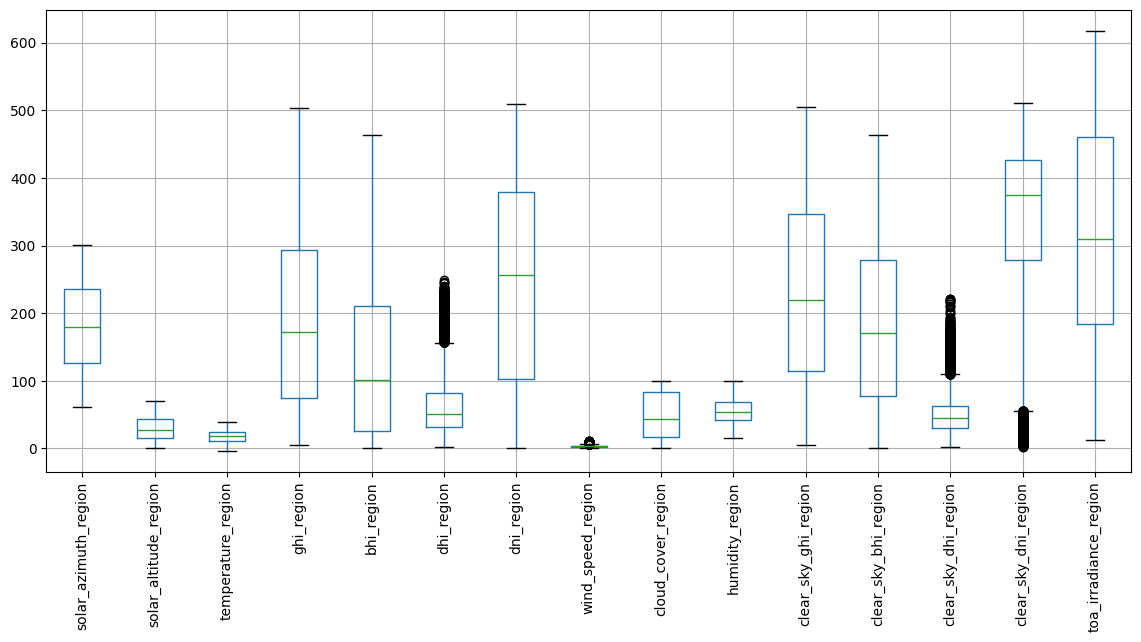

In [7]:
# Sélection des variables régionales à analyser
region_vars = [f"{v}_region" for v in variables]

# Filtrage des observations :
# on conserve uniquement les pas de temps où l'irradiation globale
# régionale est significative (GHI_region > 5)
df_filtered = df.loc[df["ghi_region"] > 5, region_vars]

# Visualisation exploratoire des distributions
# à l'aide de boxplots pour comparer les variables régionales
df_filtered.boxplot(rot=90, figsize=(14, 6));


## Rôle de la variable `Nature`

La variable `Nature` indique le niveau de validation des données issues d'éCO2mix :
- **Données définitives** : données finales et validées
- **Données consolidées** : données récentes, encore susceptibles de légères corrections

Cette variable ne décrit pas un phénomène physique du système électrique,
mais uniquement le **statut de validation des données**.


### Répartition des observations selon la variable *`Nature`*

On commence par analyser la proportion de données consolidées et définitives
dans le jeu de données.


In [8]:
df["Nature"].value_counts()

Nature
Données définitives    70128
Données consolidées    17568
Name: count, dtype: int64

### Couverture temporelle des données

On analyse ensuite les périodes temporelles couvertes par chaque type de données
afin de vérifier l'existence (ou non) d'un chevauchement temporel.


In [9]:
print(df.loc[df["Nature"] == "Données consolidées", "Date"].agg(["min", "max"]))
df.loc[df["Nature"] == "Données définitives", "Date"].agg(["min", "max"])


min   2023-12-31 23:00:00+00:00
max   2024-12-31 22:30:00+00:00
Name: Date, dtype: datetime64[ns, UTC]


min   2019-12-31 23:00:00+00:00
max   2023-12-31 22:30:00+00:00
Name: Date, dtype: datetime64[ns, UTC]

L'analyse montre qu'il n'existe **aucun chevauchement temporel** entre les données
consolidées et définitives :

- les **données définitives** couvrent les années 2019 à 2023
- les **données consolidées** couvrent l'année 2024

La variable *Nature* est donc entièrement déterminée par la variable temporelle
(*Date*) et ne constitue pas une variable explicative indépendante.


### Impact de la variable *`Nature`* sur le taux de charge photovoltaïque (`TCH`)

L'objectif de l'étude étant l'analyse de la **variabilité** de la production
photovoltaïque, on compare les statistiques descriptives et la variance du TCH
selon le type de données.


In [10]:
display(df.groupby("Nature")["tch"].describe())
print('\n',df.groupby("Nature")["tch"].var())

,count,mean,std,min,25%,50%,75%,max
Nature,,,,,,,,
Données consolidées,17568.0,16.260834,23.123976,0.0,0.0,0.13,30.9500,84.66
Données définitives,70128.0,17.026646,24.159068,0.0,0.0,0.21,32.7225,91.35



 Nature
Données consolidées    534.718254
Données définitives    583.660579
Name: tch, dtype: float64


Les analyses statistiques montrent que les données consolidées et définitives présentent des niveaux de variabilité du taux de charge photovoltaïque (TCH) comparables, sans différence structurelle significative. La variable `Nature`, qui reflète uniquement le niveau de validation des données, n'explique pas la variabilité de la production photovoltaïque et est fortement corrélée à la dimension temporelle. Elle n'est donc pas retenue comme variable explicative pour la modélisation.


In [11]:
# Suppression de la colonne Nature
df = df.drop({'Nature'}, axis=1)

## Suppression de colonnes inutiles

In [12]:
liste = ['Périmètre', 'Stockage_batterie', 'Déstockage_batterie']
for item in liste:
    print('\n', df[item].unique())


 ['PACA']

 ['-' '0' '0.0' 0.0]

 ['-' '0' '0.0' 0.0]


Certaines colonnes du jeu de données ne contiennent que peu de valeurs distinctes ou des valeurs non significatives. Par exemple :

- `Périmètre` ne contient qu'une seule valeur (`'PACA'`) → aucune variabilité, inutile pour la modélisation.
- `Stockage_batterie` et `Déstockage_batterie` contiennent essentiellement des zéros et des symboles (`'-'`, `'0'`, `'0.0'`) → pas d'information exploitable.

Ces colonnes n'apportent donc pas d'information pertinente et seront supprimées du DataFrame.

In [13]:
list(df.columns)

['Date',
 'Périmètre',
 'Consommation',
 'Solaire',
 'Ech._physiques',
 'Stockage_batterie',
 'Déstockage_batterie',
 'tco',
 'tch',
 'CRU_solar_azimuth',
 'CRU_solar_altitude',
 'SEL_solar_azimuth',
 'SEL_solar_altitude',
 'SVT_solar_azimuth',
 'SVT_solar_altitude',
 'BRA_solar_azimuth',
 'BRA_solar_altitude',
 'EYG_solar_azimuth',
 'EYG_solar_altitude',
 'CRU_toa_irradiance',
 'CRU_clear_sky_ghi',
 'CRU_clear_sky_bhi',
 'CRU_clear_sky_dhi',
 'CRU_clear_sky_dni',
 'CRU_ghi',
 'CRU_bhi',
 'CRU_dhi',
 'CRU_dni',
 'CRU_Reliability',
 'SEL_toa_irradiance',
 'SEL_clear_sky_ghi',
 'SEL_clear_sky_bhi',
 'SEL_clear_sky_dhi',
 'SEL_clear_sky_dni',
 'SEL_ghi',
 'SEL_bhi',
 'SEL_dhi',
 'SEL_dni',
 'SEL_Reliability',
 'SVT_toa_irradiance',
 'SVT_clear_sky_ghi',
 'SVT_clear_sky_bhi',
 'SVT_clear_sky_dhi',
 'SVT_clear_sky_dni',
 'SVT_ghi',
 'SVT_bhi',
 'SVT_dhi',
 'SVT_dni',
 'SVT_Reliability',
 'BRA_toa_irradiance',
 'BRA_clear_sky_ghi',
 'BRA_clear_sky_bhi',
 'BRA_clear_sky_dhi',
 'BRA_clear_sky_

In [14]:
# Suppression des colonnes
df = df.drop(columns=['Périmètre', 'Stockage_batterie', 'Déstockage_batterie'])

# Suppression des colonnes météo et énergétiques locales non nécessaires
# Les colonnes supprimées correspondent aux mesures brutes pour chaque commune/station :
# - Azimuth et altitude du soleil
# - Paramètres radiatifs : GHI, BHI, DHI, BNI, TOA, Clear sky
# - Fiabilité (Reliability)
# - Paramètres météorologiques : température, vitesse du vent, nébulosité, humidité
# Ces colonnes sont redondantes car nous avons déjà créé les variables régionales agrégées
df_drop = df.drop(columns=['CRU_solar_azimuth', 'CRU_solar_altitude', 'SEL_solar_azimuth', 'SEL_solar_altitude',
 'SVT_solar_azimuth', 'SVT_solar_altitude', 'BRA_solar_azimuth', 'BRA_solar_altitude', 'EYG_solar_azimuth',
 'EYG_solar_altitude', 'CRU_toa_irradiance', 'CRU_clear_sky_ghi', 'CRU_clear_sky_bhi', 'CRU_clear_sky_dhi',
 'CRU_clear_sky_dni', 'CRU_ghi', 'CRU_bhi', 'CRU_dhi', 'CRU_dni', 'CRU_Reliability', 'SEL_toa_irradiance',
 'SEL_clear_sky_ghi', 'SEL_clear_sky_bhi', 'SEL_clear_sky_dhi', 'SEL_clear_sky_dni', 'SEL_ghi', 'SEL_bhi',
 'SEL_dhi', 'SEL_dni', 'SEL_Reliability', 'SVT_toa_irradiance', 'SVT_clear_sky_ghi', 'SVT_clear_sky_bhi',
 'SVT_clear_sky_dhi', 'SVT_clear_sky_dni', 'SVT_ghi', 'SVT_bhi', 'SVT_dhi', 'SVT_dni', 'SVT_Reliability',
 'BRA_toa_irradiance', 'BRA_clear_sky_ghi', 'BRA_clear_sky_bhi', 'BRA_clear_sky_dhi', 'BRA_clear_sky_dni',
 'BRA_ghi', 'BRA_bhi', 'BRA_dhi', 'BRA_dni', 'BRA_Reliability', 'EYG_toa_irradiance', 'EYG_clear_sky_ghi',
 'EYG_clear_sky_bhi', 'EYG_clear_sky_dhi', 'EYG_clear_sky_dni', 'EYG_ghi', 'EYG_bhi', 'EYG_dhi', 'EYG_dni',
 'EYG_Reliability', 'CRU_temperature', 'CRU_wind_speed', 'CRU_cloud_cover', 'CRU_humidity', 'SEL_temperature',
 'SEL_wind_speed', 'SEL_cloud_cover', 'SEL_humidity', 'SVT_temperature', 'SVT_wind_speed', 'SVT_cloud_cover',
 'SVT_humidity', 'BRA_temperature', 'BRA_wind_speed', 'BRA_cloud_cover', 'BRA_humidity', 'EYG_temperature',
 'EYG_wind_speed', 'EYG_cloud_cover', 'EYG_humidity'])

# Sauvegarde du DataFrame réduit ne contenant que les variables régionales
# météo et énergie pour analyses ultérieures
df_drop.to_csv(output_directory + "paca_meteo_energie.csv", index=False)


Les composantes temporelles (année, mois, jour, heure) sont extraites afin de décrire
les effets **intra‑journaliers (horaires), mensuels et saisonniers** sur la production solaire.

In [15]:
# Extraire l'année à partir de la colonne Date
df['year']  = df['Date'].dt.year

# Extraire le mois à partir de la colonne Date
df['month'] = df['Date'].dt.month

# Extraire le jour à partir de la colonne Date
df['day'] = df['Date'].dt.day

# Extraire l'heure à partir de la colonne Date
df['hour'] = df['Date'].dt.hour

# Vérification
df[['Date', 'year', 'month', 'day', 'hour']].head()

,Date,year,month,day,hour
0,2019-12-31 23:00:00+00:00,2019,12,31,23
1,2019-12-31 23:30:00+00:00,2019,12,31,23
2,2020-01-01 00:00:00+00:00,2020,1,1,0
3,2020-01-01 00:30:00+00:00,2020,1,1,0
4,2020-01-01 01:00:00+00:00,2020,1,1,1


## Analyse de la variabilité mensuelle du TCH

### Définition de TCH
Le **TCH (Taux de Charge ou Facteur de Charge)** mesure l'utilisation réelle d'une capacité de production électrique par rapport à ce qu'elle pourrait produire à plein régime.  
Il se calcule ainsi :

$$
\text{TCH} = \frac{\text{Production réelle}}{\text{Capacité installée}}
$$

### Variabilité
La **variabilité** nous indique **à quel point la production réelle fluctue autour de la moyenne** :

- Une production stable → faible variabilité.  
- Une production irrégulière → forte variabilité.

Pour comparer des périodes avec des moyennes différentes, on utilise le **coefficient de variation (CV)** :

$$
\text{CV} = \frac{\text{Écart-type } (\sigma)}{\text{Moyenne }(\mu)}
$$

- CV élevé → forte variabilité de la production par rapport à la moyenne..  
- CV faible → faible variabilité, indiquant une production plus régulière par rapport à la moyenne.  


### Méthodes utilisées

#### 1. **Statistiques horaires** : 

In [16]:
# df_day = df[df["hour"].between(4,19)]
df_day = df.loc[df.ghi_region > 0]

# Calculer les statistiques horaires pour la production solaire
hour_stats = df_day.groupby('hour')['tch'].describe() 

# Ajouter le coefficient de variation
hour_stats['cv'] = hour_stats['std'] / hour_stats['mean']

hour_stats


,count,mean,std,min,25%,50%,75%,max,cv
hour,,,,,,,,,
4,919.0,0.274820,0.399596,0.00,0.0000,0.000,0.4950,1.98,1.454026
5,1834.0,2.646549,2.557315,0.00,0.2800,2.000,4.1000,9.58,0.966283
6,2669.0,8.958037,7.675790,0.00,1.4500,7.800,14.4900,28.90,0.856861
7,3654.0,17.356894,14.579589,0.00,2.4325,15.390,30.3800,50.44,0.839988
8,3654.0,31.323664,18.335694,0.28,14.1600,32.845,47.7100,66.62,0.585362
9,3654.0,43.789078,19.471131,0.82,28.2950,47.705,60.7175,80.85,0.444657
10,3654.0,51.794220,19.734675,1.64,38.6350,56.065,68.2000,88.38,0.381021
11,3654.0,54.966749,19.651687,2.56,42.7375,59.505,71.1400,91.35,0.357520
12,3654.0,54.085145,19.502330,2.25,41.9350,58.145,70.4000,91.30,0.360586


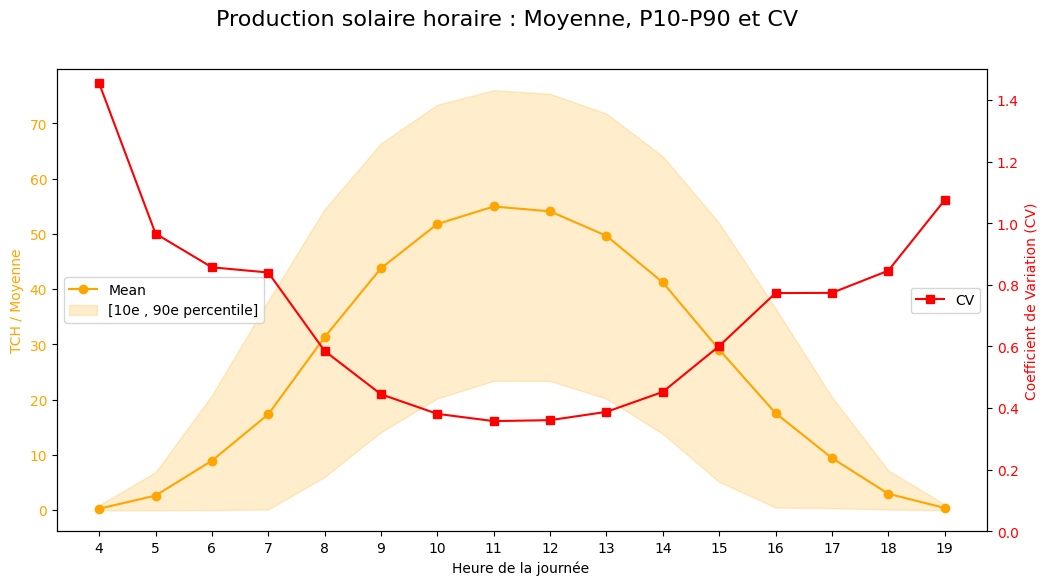

In [17]:
heures = hour_stats.index
mean = hour_stats['mean']
std = hour_stats['std']
cv = hour_stats['cv']

# Calcul des percentiles
p10 = hour_stats['p10'] = df_day.groupby('hour')['tch'].quantile(0.10)
p90 = hour_stats['p90'] = df_day.groupby('hour')['tch'].quantile(0.90)

# Figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Courbe moyenne + bande
ax1.plot(heures, mean, marker='o', color='orange', label='Mean')
ax1.fill_between(heures, p10, p90, color='orange', alpha=0.2, label='[10e , 90e percentile]')
ax1.set_xlabel('Heure de la journée ')
ax1.set_ylabel('TCH / Moyenne', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_xticks(heures)

# CV sur axe secondaire
ax2 = ax1.twinx()
ax2.plot(heures, cv, marker='s', color='red', label='CV')
ax2.set_ylabel('Coefficient de Variation (CV)', color='red')
ax2.set_ylim(0, 1.5)
ax2.tick_params(axis='y', labelcolor='red')

# Titres et légendes
fig.suptitle('Production solaire horaire : Moyenne, P10-P90 et CV', fontsize=16)
ax1.legend(loc='center left')
ax2.legend(loc='center right')

plt.show()


**Interprétation du graphique**

Le graphique montre, pour chaque heure de la journée :  
- la **moyenne de la production solaire** (`mean`) en orange ;  
- la **bande** (zone orange claire) représentant la **dispersion absolue** autour de la moyenne (écart-type) ;  
- le **coefficient de variation (CV)** (courbe rouge sur l'axe secondaire), qui indique la **variabilité relative par rapport à la moyenne**.


**Observations**

1. **Variabilité absolue**
    - La bande est **très étroite tôt le matin (4–5h) et en soirée (18–19h)** : la production est faible et la dispersion absolue reste limitée.
    - Elle devient **très large entre 6h et 12h**, lorsque la production solaire augmente fortement et varie davantage d'un jour à l'autre.
    - L'après-midi (13–17h), la bande **se resserre progressivement** à mesure que la production moyenne diminue.


2. **Variabilité relative (CV)**
    - Le **CV est minimal autour de midi (≈ 0,36–0,39 entre 10h et 13h)** :  
  la production est élevée et **relativement stable par rapport à sa moyenne**.
    - Le **CV est élevé tôt le matin (≈ 0,76–0,98 entre 4h et 7h)** et en fin de journée (**≈ 0,55–0,72 entre 15h et 18h**) :  
  la production est plus faible et les fluctuations représentent une **part importante de la moyenne**.


3. **La variabilité ne suit pas le niveau moyen**
    - Les heures avec une **faible moyenne** (tôt le matin, fin de journée) présentent souvent un **CV élevé**, car une variation modérée en valeur absolue représente une grande part de la moyenne.
    - Les heures avec une **moyenne élevée** (≈ 8h–15h) ont un **CV plus faible**, même si l'écart-type absolu est important : la production est alors **plus stable proportionnellement**.


**Conclusion**
- La production solaire est **faible et relativement instable en proportion** en début et fin de journée (CV élevé).
- Elle est **maximale et la plus régulière autour de midi**, caractérisée par une **forte moyenne et un faible CV**.

Cette analyse permet d'identifier les **heures les plus stables** (milieu de journée) et celles où la **variabilité relative est la plus forte** (matin et fin d'après-midi).


#### 2. **Statistiques mensuelles** :

In [18]:
# Calcul des statistiques de base
monthly_stats = df_day.groupby('month')['tch'].describe()

# Calcul du coefficient de variation
monthly_stats['cv'] = monthly_stats['std'] / monthly_stats['mean']

monthly_stats


,count,mean,std,min,25%,50%,75%,max,cv
month,,,,,,,,,
1,3057.0,22.256271,18.396766,0.0,5.1500,18.380,38.1500,63.82,0.826588
2,3102.0,28.600061,22.015841,0.0,7.6050,25.940,48.6800,73.50,0.769783
3,3851.0,31.947627,23.877277,0.0,8.6150,30.350,53.1650,81.16,0.747388
4,4169.0,34.985303,25.689759,0.0,10.1100,33.870,58.0500,84.66,0.734301
5,4702.0,34.554230,25.782443,0.0,9.0700,33.175,58.4075,87.81,0.746144
6,4753.0,35.051990,25.489922,0.0,8.8400,34.870,58.1500,82.52,0.727203
7,4804.0,38.626873,26.678913,0.0,11.6875,41.600,63.4750,86.99,0.690683
8,4457.0,39.597124,27.113529,0.0,12.4900,43.060,65.0000,91.35,0.684735
9,3883.0,34.262683,24.502496,0.0,10.4400,33.580,56.8500,82.87,0.715137


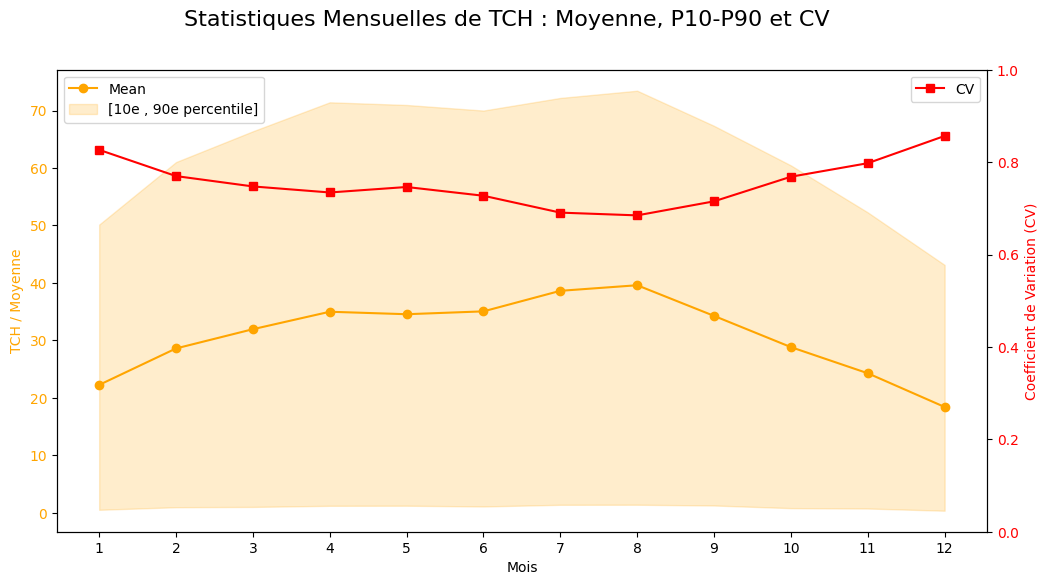

In [19]:
mois = monthly_stats.index
mean = monthly_stats['mean']
std = monthly_stats['std']
cv = monthly_stats['cv']

# Calcul des percentiles
p10 = monthly_stats['p10'] = df_day.groupby('month')['tch'].quantile(0.10)
p90 = monthly_stats['p90'] = df_day.groupby('month')['tch'].quantile(0.90)

# Créer la figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Tracer mean et std sur le même axe
ax1.plot(mois, mean, marker='o', color='orange', label='Mean')
ax1.fill_between(mois, p10, p90, color='orange', alpha=0.2, label='[10e , 90e percentile]')
ax1.set_xlabel('Mois')
ax1.set_ylabel('TCH / Moyenne', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_xticks(mois)

# Tracer CV sur un axe secondaire
ax2 = ax1.twinx()
ax2.plot(mois, cv, marker='s', color='red', label='CV')
ax2.set_ylabel('Coefficient de Variation (CV)', color='red')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='y', labelcolor='red')

# Titres et légendes
fig.suptitle('Statistiques Mensuelles de TCH : Moyenne, P10-P90 et CV', fontsize=16)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()


**Interprétation du graphique**

Le graphique montre, pour chaque mois :  
- la **moyenne du TCH** (courbe orange) ;  
- la **bande** (zone orange claire) représentant la **dispersion absolue** autour de la moyenne (écart-type) ;  
- le **coefficient de variation (CV)** (courbe rouge sur l'axe secondaire), qui mesure la **variabilité relative par rapport à la moyenne**.


**Observations**

1. **Variabilité absolue (bande)**
    - La bande est **plus large entre juin et août**, indiquant un **écart-type absolu élevé**, lié à des niveaux de production plus importants.
    - Elle est **plus étroite en hiver (décembre–janvier)**, lorsque la production moyenne est plus faible en valeur absolue.


2. **Variabilité relative (CV)**
    - Le **CV est le plus élevé en hiver**, notamment en **décembre (≈ 0,78)** et **janvier (≈ 0,76)** :  
  la production est faible et les fluctuations représentent une **grande part de la moyenne**.
    - Le **CV diminue progressivement vers l'été**, avec un minimum en **juillet–août (≈ 0,64–0,65)** :  
  la production est plus **stable proportionnellement**, même si elle reste variable en valeur absolue.
    - À l'automne (septembre–novembre), le CV **remonte progressivement**, traduisant une variabilité relative croissante à mesure que la production moyenne diminue.


3. **La variabilité ne suit pas le niveau moyen**
    - Les mois à **forte moyenne** (été) peuvent présenter une **dispersion absolue importante**, mais un **CV faible**, ce qui indique une production relativement régulière.
    - À l'inverse, les mois à **faible moyenne** (hiver) ont un **CV élevé**, car des variations modérées en valeur absolue deviennent importantes **en proportion de la moyenne**.


**Conclusion**
- Le TCH est **proportionnellement plus instable en hiver**, malgré des niveaux de production plus faibles.
- En été, la production est **plus régulière relativement à son niveau moyen**, même si les fluctuations absolues sont importantes.
- Le coefficient de variation permet ainsi de **comparer correctement les mois entre eux**, indépendamment des différences de niveau moyen, et d'identifier les périodes **les plus stables et les plus variables**.


#### 3. **Statistiques saisonnières** :
En plus de l'échelle mensuelle, il est souvent plus parlant de raisonner en **saisons** :

- **Hiver** : période à faible hauteur solaire, jours courts, météo plus perturbée  
- **Printemps** : transition vers des jours plus longs et une irradiance croissante  
- **Été** : hauteur solaire maximale, forte irradiance, durée du jour maximale  
- **Automne** : retour à des conditions plus instables et jours plus courts

On définit une fonction `saison(row)` qui attribue une saison à chaque date en fonction du mois et du jour, en se basant sur les dates officielles de début des saisons.

Ces saisons servent ensuite à :

- calculer des **statistiques de TCH par saison**,  
- comparer la **stabilité relative** de la production solaire d'une saison à l'autre via le **coefficient de variation (CV)**.

In [20]:
# Fonction pour déterminer la saison 
def saison(row):
    mois = row['month']
    jour = row['day']

    if (mois == 12 and jour >= 21) or (mois <= 2) or (mois == 3 and jour < 21):
        return "Hiver"
    elif (mois == 3 and jour >= 21) or (mois in [4,5]) or (mois == 6 and jour < 21):
        return "Printemps"
    elif (mois == 6 and jour >= 21) or (mois in [7,8]) or (mois == 9 and jour < 21):
        return "Été"
    else:  
        return "Automne"

df_day['saison'] = df_day.apply(saison, axis=1)


/tmp/ipykernel_26047/2485505617.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['saison'] = df_day.apply(saison, axis=1)


In [21]:
# Calculer les statistiques par saison pour la production solaire
season_stats = df_day.groupby('saison')['tch'].describe()

# Ajouter le coefficient de variation
season_stats['cv'] = season_stats['std'] / season_stats['mean']

season_stats

,count,mean,std,min,25%,50%,75%,max,cv
saison,,,,,,,,,
Automne,9711.0,25.911372,20.955816,0.0,6.1500,22.330,43.67,76.90,0.808750
Hiver,9625.0,26.214888,21.146890,0.0,6.3500,22.500,43.64,76.50,0.806675
Printemps,13454.0,34.632616,25.583896,0.0,9.2625,33.535,58.00,87.81,0.738723
Été,13494.0,37.763026,26.410654,0.0,11.3325,39.570,62.16,91.35,0.699379


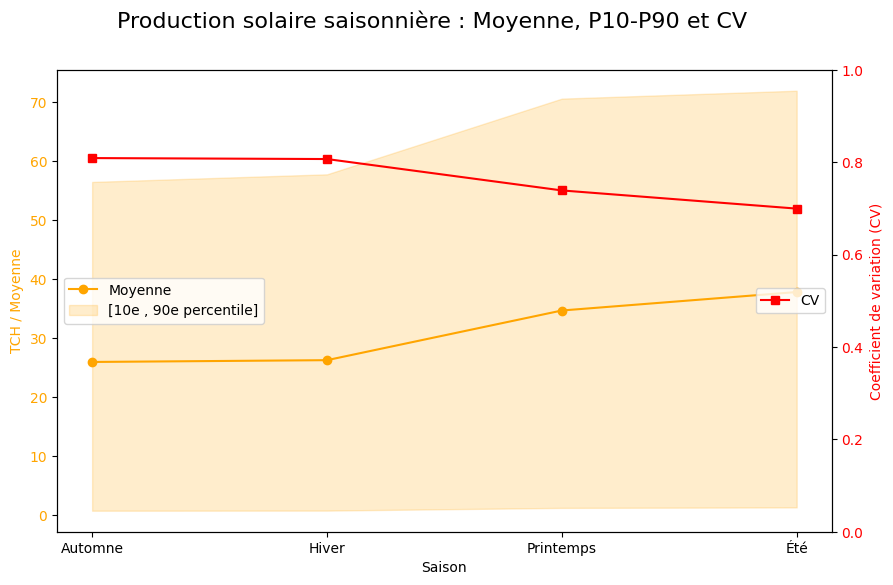

In [22]:
saisons = season_stats.index
mean = season_stats['mean']
std = season_stats['std']
cv = season_stats['cv']

# Calcul des percentiles
p10 = season_stats['p10'] = df_day.groupby('saison')['tch'].quantile(0.10)
p90 = season_stats['p90'] = df_day.groupby('saison')['tch'].quantile(0.90)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Courbe moyenne + bande [0, mean + std]
ax1.plot(saisons, mean, marker='o', color='orange', label='Moyenne')
ax1.fill_between(saisons, p10, p90, color='orange', alpha=0.2, label='[10e , 90e percentile]')
ax1.set_xlabel('Saison')
ax1.set_ylabel('TCH / Moyenne', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')

# CV sur axe secondaire
ax2 = ax1.twinx()
ax2.plot(saisons, cv, marker='s', color='red', label='CV')
ax2.set_ylabel('Coefficient de variation (CV)', color='red')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='y', labelcolor='red')

# Titres et légendes
fig.suptitle('Production solaire saisonnière : Moyenne, P10-P90 et CV', fontsize=16)
ax1.legend(loc='center left')
ax2.legend(loc='center right')

plt.show()


**Interprétation du graphique**

Le graphique montre, pour chaque saison :  
- la **moyenne de la production solaire** (`mean`) en orange ;  
- la **bande** (zone orange claire) représentant la **dispersion absolue** autour de la moyenne (écart-type) ;  
- le **coefficient de variation (CV)** (courbe rouge sur l'axe secondaire), qui mesure la **variabilité relative par rapport à la moyenne**.

**Observations**

**1. Variabilité absolue**
    
- La **bande est plus large au printemps et en été** :  
  l'écart-type absolu est plus élevé car la production solaire est plus importante et varie davantage d'un jour à l'autre.
- La **bande est plus étroite en automne et en hiver** :  
  la production moyenne est plus faible, ce qui limite la dispersion absolue.


**2. Variabilité relative (CV)**

- Le **CV est le plus élevé en automne et en hiver (≈ 0,75)** :  
  les fluctuations représentent une part importante de la moyenne, indiquant une **production proportionnellement plus instable**.
- Le **CV diminue au printemps (≈ 0,70)** et atteint son minimum en **été (≈ 0,66)** :  
  la production est alors **plus régulière relativement à son niveau moyen**, malgré des variations absolues importantes.


**Conclusion**
- La production solaire est **proportionnellement plus stable au printemps et en été**, périodes de forte production.
- L'automne et l'hiver présentent une **production plus instable relativement à la moyenne**, bien que la dispersion absolue soit plus faible.
- Le coefficient de variation permet ainsi de **comparer les saisons indépendamment de leur niveau moyen** et de mieux identifier les périodes les plus régulières et les plus variables.


## Lien entre TCH et GHI régional

**GHI (Global Horizontal Irradiance)** désigne la quantité totale de rayonnement solaire reçue par une surface horizontale, incluant la composante directe et la composante diffuse.

Une fois `GHI_region` construite, l'objectif est d'analyser la sensibilité du TCH aux variations de l'irradiance globale régionale.  

On étudie comment le TCH évolue en fonction des hausses ou baisses du GHI afin de mettre en évidence une relation entre l'ensoleillement régional et le comportement du TCH.

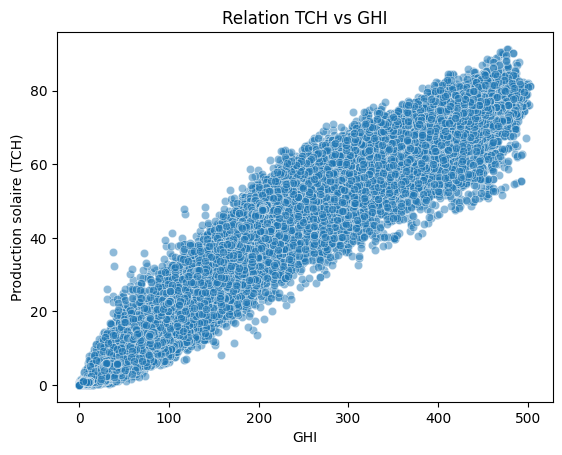

In [23]:
sns.scatterplot(x='ghi_region', y='tch', data=df_day, alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('Production solaire (TCH)')
plt.title('Relation TCH vs GHI')
# sns.relplot(x='GHI_region', y='TCH', data=df, alpha=0.5, hue='cloud_category', col='saison', col_wrap=2)
plt.show()


Afin d'évaluer l'existence et l'intensité d'un lien statistique entre le GHI régional et le TCH, on calcule deus coefficients de corrélation (corrélation de **Pearson** et corrélation de **Spearman**) ainsi que leurs p-values associées, permettant d'apprécier la significativité de la relation observée.

In [24]:
corr_p, p_value_p = pearsonr(df_day['ghi_region'], df_day['tch'])
corr_s, p_value_s = spearmanr(df_day['ghi_region'], df_day['tch'])
print(f"Corrélation Pearson : {corr_p}")
print(f"P-value : {p_value_p}")
print(f"Corrélation Spearman : {corr_s}")
print(f"P-value : {p_value_s}")


Corrélation Pearson : 0.9663395274455029
P-value : 0.0
Corrélation Spearman : 0.9762104523824806
P-value : 0.0


Les résultats montrent une **corrélation très forte et positive** entre le GHI régional et le TCH.  
Les coefficients, proches de 1, indiquent que le TCH augmente fortement lorsque le GHI régional augmente.  
Les p-values nulles confirment que cette relation est **hautement significative statistiquement**.


### Statistiques descriptives en fonction des niveaux d'irradiance

Dans cette étape, la production TCH est étudiée en fonction de classes de GHI définies par intervalles réguliers. Pour chaque bin d'irradiance, des statistiques descriptives sont calculées, notamment la moyenne, l'écart-type, les percentiles P10 et P90, ainsi que le coefficient de variation (CV).

Cette approche permet comme avant de caractériser la relation entre l'intensité de l'irradiance et la production solaire selon trois dimensions complémentaires : le niveau moyen de production, la dispersion absolue autour de cette moyenne et la variabilité relative au sein de chaque régime d'irradiance. 


/tmp/ipykernel_26047/2840214588.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['ghi_bin'] = pd.cut(df_day['ghi_region'], bins)
/tmp/ipykernel_26047/2840214588.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ghi_stats = df_day.groupby('ghi_bin')['tch'].describe()
/tmp/ipykernel_26047/2840214588.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ghi_stat

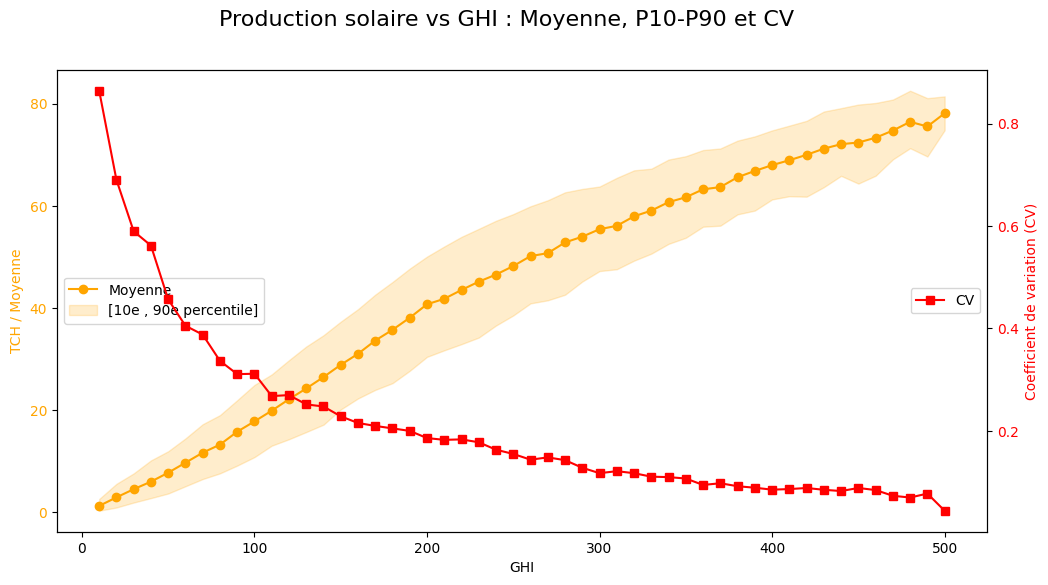

In [25]:
# Définir les bins
bins = range(5, int(df_day['ghi_region'].max()) + 50, 10)
df_day['ghi_bin'] = pd.cut(df_day['ghi_region'], bins)

# Stats par bin
ghi_stats = df_day.groupby('ghi_bin')['tch'].describe()
ghi_stats['cv'] = ghi_stats['std'] / ghi_stats['mean']

# Percentiles P10 et P90
ghi_stats['p10'] = df_day.groupby('ghi_bin')['tch'].quantile(0.10)
ghi_stats['p90'] = df_day.groupby('ghi_bin')['tch'].quantile(0.90)

# Convertir l'IntervalIndex en valeur numérique (milieu du bin)
ghi_stats['GHI_mid'] = ghi_stats.index.map(lambda x: x.mid)

# Variables pour le tracé
ghi = ghi_stats['GHI_mid']
mean = ghi_stats['mean']
cv = ghi_stats['cv']
p10 = ghi_stats['p10']
p90 = ghi_stats['p90']

# Tracé
fig, ax1 = plt.subplots(figsize=(12, 6))

# Courbe moyenne + bande P10-P90
ax1.plot(ghi, mean, marker='o', color='orange', label='Moyenne')
ax1.fill_between(ghi, p10, p90, color='orange', alpha=0.2, label='[10e , 90e percentile]')
ax1.set_xlabel('GHI')
ax1.set_ylabel('TCH / Moyenne', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')

# CV sur axe secondaire
ax2 = ax1.twinx()
ax2.plot(ghi, cv, marker='s', color='red', label='CV')
ax2.set_ylabel('Coefficient de variation (CV)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Titres et légendes
fig.suptitle('Production solaire vs GHI : Moyenne, P10-P90 et CV', fontsize=16)
ax1.legend(loc='center left')
ax2.legend(loc='center right')

plt.show()


**Interprétation du graphique GHI – TCH**

Le graphique présente, pour chaque classe de GHI, la moyenne de TCH, l'intervalle P10–P90 et le coefficient de variation (CV).

**Principales observations**

1. La moyenne de TCH augmente régulièrement avec le GHI, ce qui traduit une relation cohérente entre irradiance et production.

2. La dispersion absolue (P10–P90) s'élargit avec le GHI. Aux faibles GHI, les valeurs restent concentrées à bas niveau. Aux GHI moyens et élevés, les valeurs sont plus étalées en valeur absolue autour de la moyenne.

3. Le CV est élevé aux faibles GHI, ce qui indique une variabilité relative importante pour une production moyenne faible. Le CV diminue progressivement lorsque le GHI augmente, la production devient alors plus stable proportionnellement à la moyenne.

**Conclusion**

La production est faible et instable en proportion aux faibles irradiances, alors qu'elle devient élevée et relativement plus stable aux irradiances élevées. La variabilité absolue augmente avec la production, tandis que la variabilité relative diminue avec le GHI.


In [26]:
zenith_deg = 90.0 - df_day["solar_altitude_region"]
zenith_rad = np.deg2rad(zenith_deg)
df_day["cos_zenith_region"] = np.cos(zenith_rad)

# Mettre 0 la nuit si altitude <= 0
df_day.loc[df_day["solar_altitude_region"] <= 0, "cos_zenith_region"] = 0

/tmp/ipykernel_26047/3668152542.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day["cos_zenith_region"] = np.cos(zenith_rad)


**Interprétation :**

- `cos_zenith_region` proche de 1 → soleil très haut (midi, été) → TCH potentiel max
- `cos_zenith_region` proche de 0 → soleil rasant / nuit → très peu de production possible
  
**Calcul de l'angle d'incidence solaire sur les panneaux**

`cos_incidence` mesure l'angle entre la surface du panneau et la direction du soleil.

Formule trigonométrique pour un panneau incliné et orienté :

$$
\cos(\theta) = \sin(\alpha) \cdot \cos(\beta) + \cos(\alpha) \cdot \sin(\beta) \cdot \cos(\gamma_s - \gamma_p)
$$

- **$\alpha$** = altitude du soleil  
- **$\beta$** = inclinaison des panneaux par rapport à l'horizontale, en degrés  
- **$\gamma_s$** = azimut du soleil  
- **$\gamma_p$** = orientation (azimut) des panneaux, en degrés.  

**Interprétation :**

- `cos_incidence proche 1` → soleil perpendiculaire au panneau → production maximale  
- `cos_incidence proche 0` → soleil très oblique → peu de production  
- `cos_incidence < 0` → soleil derrière le panneau → pas de production


In [27]:
# Hypothèses
beta_deg = 30.0        # inclinaison des panneaux
gamma_p_deg = 180.0    # azimuth panneaux (Sud)

alpha_rad = np.deg2rad(df_day["solar_altitude_region"])
gamma_s_rad = np.deg2rad(df_day["solar_azimuth_region"])
beta_rad = np.deg2rad(beta_deg)
gamma_p_rad = np.deg2rad(gamma_p_deg)

df_day["cos_incidence_region"] = (
    np.sin(alpha_rad) * np.cos(beta_rad)
    + np.cos(alpha_rad) * np.sin(beta_rad) * np.cos(gamma_s_rad - gamma_p_rad)
)

# On met 0 la nuit ou quand le soleil est derrière les panneaux
df_day.loc[(df_day["solar_altitude_region"] <= 0) | (df_day["cos_incidence_region"] < 0), "cos_incidence_region"] = 0


/tmp/ipykernel_26047/2259223284.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day["cos_incidence_region"] = (


**Corrélation entre angles solaires et production TCH**

In [28]:
print("Corr cos_zenith/TCH :", pearsonr(df_day["cos_zenith_region"], df_day["tch"]))
print("Corr cos_incidence/TCH :", pearsonr(df_day["cos_incidence_region"], df_day["tch"]))
print("Corr cos_zenith_region/cos_incidence_region :", pearsonr(df_day["cos_zenith_region"], df_day["cos_incidence_region"]))


Corr cos_zenith/TCH : PearsonRResult(statistic=np.float64(0.8695576091898596), pvalue=np.float64(0.0))
Corr cos_incidence/TCH : PearsonRResult(statistic=np.float64(0.8283517488970029), pvalue=np.float64(0.0))
Corr cos_zenith_region/cos_incidence_region : PearsonRResult(statistic=np.float64(0.8674170275444192), pvalue=np.float64(0.0))


**Analyse des corrélations avec le TCH**

Les corrélations entre le TCH et les variables géométriques `cos_zenith_region` et `cos_incidence_region` sont très élevées. Cela confirme que la **position du soleil** dans le ciel (géométrie solaire) explique une part importante de la variabilité du TCH.

On observe que :  
- `cos_zenith_region` corrèle légèrement mieux avec le TCH que `cos_incidence_region`.  
- `cos_incidence_region` repose sur une **hypothèse d'orientation** moyenne des panneaux (inclinaison et azimuth).  
  Si cette hypothèse ne reflète pas fidèlement la réalité du parc photovoltaïque (orientations variées, installations Est/Ouest, toitures, etc.), cette variable devient moins représentative.  
- À l'inverse, `cos_zenith_region` dépend uniquement de la **hauteur du soleil** et reste valable quelles que soient les orientations réelles des installations.  

Par ailleurs, les deux variables `cos_zenith_region` et `cos_incidence_region` sont fortement corrélées entre elles, ce qui les rend presque **redondantes** d'un point de vue statistique.


**Conclusion:**
`cos_incidence_region` n'apporte pas d'information supplémentaire significative par rapport à cos_zenith_region.
Dans la suite de l'analyse, nous conservons donc **`cos_zenith_region` comme feature principale**.


## Lien entre TCH et nébulosité régional

L'analyse précédente a montré comment la production TCH évolue en fonction du GHI, avec une augmentation de la moyenne et une diminution progressive de la variabilité relative lorsque l'irradiance augmente. Cependant, le GHI ne reflète pas uniquement l'intensité solaire ; il est également influencé par la présence et la dynamique des nuages.

Pour mieux comprendre le rôle spécifique de la couverture nuageuse dans la variabilité de la production, nous regroupons maintenant les données selon des **catégories de nébulosité** (clair, partiellement clair, nuageux, très nuageux) et observons la distribution de TCH au sein de chaque catégorie à l'aide d'un boxplot. Cette étape permet de distinguer les effets liés à la radiation solaire de ceux associés aux conditions atmosphériques et d'identifier plus précisément comment les nuages impactent la stabilité et l'amplitude de la production solaire.


/tmp/ipykernel_26047/2412809355.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['cloud_category'] = pd.cut(df_day['cloud_cover_region'], bins=bins, labels=labels, include_lowest=True)


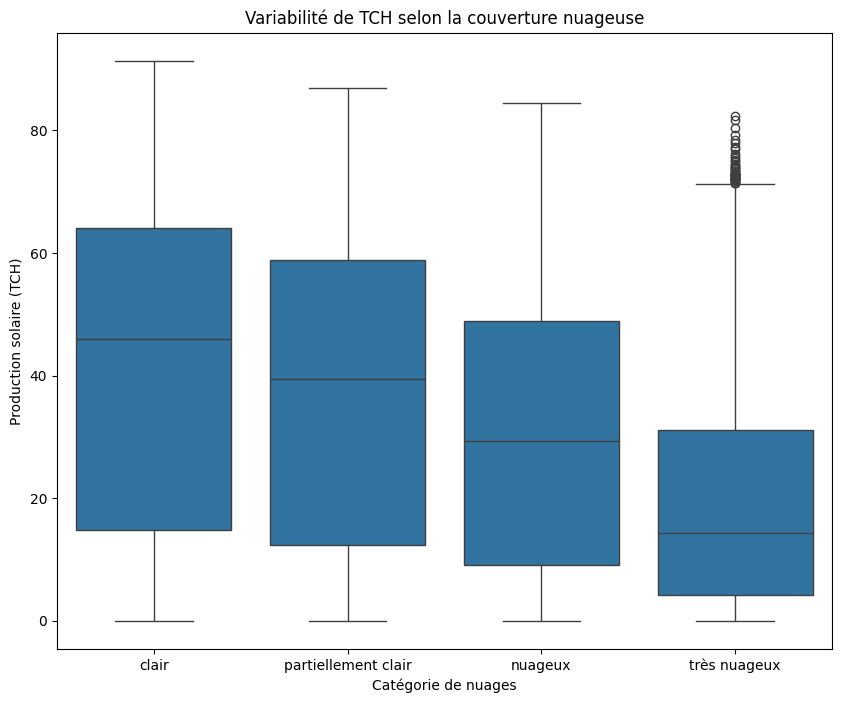

In [29]:
bins = [0, 20, 50, 80, 100]
labels = ['clair', 'partiellement clair', 'nuageux', 'très nuageux']
df_day['cloud_category'] = pd.cut(df_day['cloud_cover_region'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10,8))
sns.boxplot(x='cloud_category', y='tch', data=df_day)
plt.xlabel('Catégorie de nuages')
plt.ylabel('Production solaire (TCH)')
plt.title('Variabilité de TCH selon la couverture nuageuse')
plt.show()


Le boxplot montre la distribution de la production solaire (TCH) pour différentes catégories de couverture nuageuse. La médiane, la dispersion et les valeurs extrêmes permettent d'identifier l'impact des nuages sur le niveau et la variabilité de la production.

- **Clair**: Production moyenne élevée avec des valeurs maximales importantes. La dispersion en valeur absolue est large, ce qui correspond à un régime de production intense mais étendu.

- **Partiellement clair**: Production intermédiaire, avec une variabilité marquée liée à l'alternance entre ensoleillement et passages nuageux.

- **Nuageux**: Production plus faible et plus homogène, avec une dispersion resserrée autour de valeurs modérées.

- **Très nuageux**: Production basse en moyenne. La majorité des valeurs se situe dans la zone basse, avec quelques pics ponctuels associés à des éclaircies.


### Passage d'une nébulosité observée à une nébulosité radiative (CSI)

La classification précédente repose sur la **nébulosité régionale exprimée en pourcentage**, qui décrit l'état du ciel d'un point de vue météorologique. Toutefois, cette variable ne quantifie pas directement l'**atténuation effective du rayonnement solaire** reçue au sol.

Afin de mieux relier les conditions atmosphériques à la production photovoltaïque, nous introduisons l'**indice de ciel clair (Clear Sky Index – CSI)**, défini comme le rapport entre l'irradiance globale mesurée et l'irradiance théorique en conditions de ciel clair :

$$
\mathrm{CSI} = \frac{\mathrm{GHI}}{\mathrm{GHI}_{\text{clear-sky}}}
$$

Cette approche permet de regrouper les données selon des **catégories de nébulosité radiative**, basées sur la réduction réelle du rayonnement solaire. La cellule suivante analyse ainsi la variabilité de la production solaire (TCH) en fonction de ces classes de CSI à l'aide d'un boxplot.


/tmp/ipykernel_26047/187324705.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day["CSI"] = df_day["ghi_region"] / df_day["clear_sky_ghi_region"]
/tmp/ipykernel_26047/187324705.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['cloud_category_CSI'] = pd.cut(df_day['CSI'], bins=bins, labels=labels, include_lowest=True)


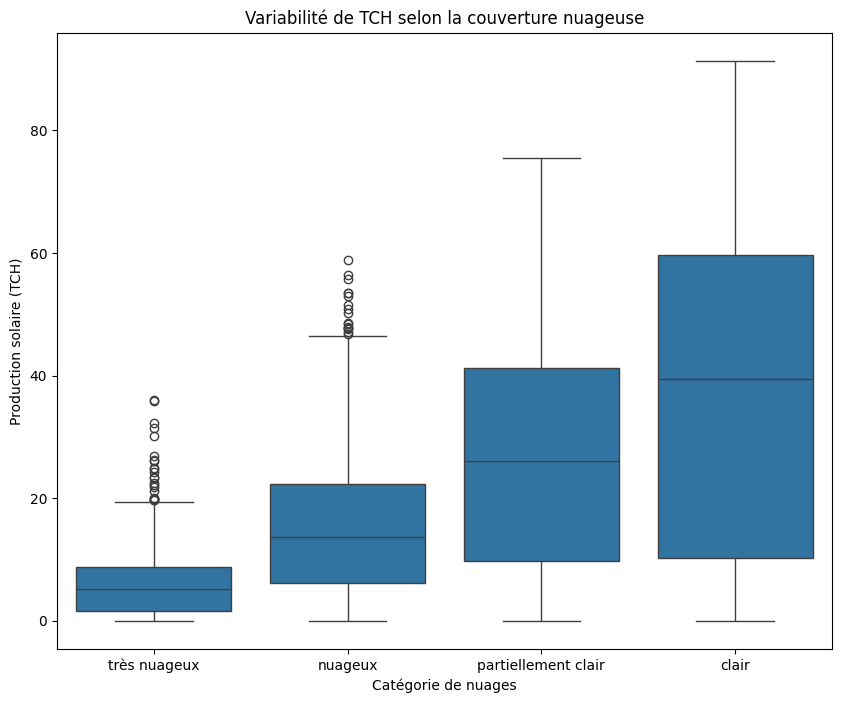

In [30]:
bins = [0, 0.2, 0.5, 0.8, 1]
labels = ['très nuageux', 'nuageux', 'partiellement clair', 'clair']
df_day["CSI"] = df_day["ghi_region"] / df_day["clear_sky_ghi_region"]
df_day['cloud_category_CSI'] = pd.cut(df_day['CSI'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10,8))
sns.boxplot(x='cloud_category_CSI', y='tch', data=df_day)
plt.xlabel('Catégorie de nuages')
plt.ylabel('Production solaire (TCH)')
plt.title('Variabilité de TCH selon la couverture nuageuse')
plt.show()

**Comparaison entre nébulosité observée et nébulosité radiative**

L'analyse basée sur l'indice de ciel clair (CSI) met en évidence un **comportement globalement identique** à celui observé précédemment avec la nébulosité régionale exprimée en pourcentage.

Dans les deux approches, la production solaire (TCH) :
- diminue progressivement lorsque la couverture nuageuse augmente,
- devient plus faible et plus homogène sous des conditions fortement nuageuses.

Cette cohérence entre les deux classifications confirme que la **variabilité de TCH est principalement gouvernée par l'atténuation radiative induite par les nuages**, et non uniquement par leur présence apparente. L'utilisation du CSI permet toutefois une interprétation plus directement liée aux mécanismes physiques de réduction de l'irradiance, renforçant ainsi la robustesse de l'analyse.


### Lecture par *régimes de ciel* : classes de **GHI**

Le **GHI** est une **variable intégratrice** qui “voit” à la fois :
- la géométrie solaire (cycle journalier / saison),
- et surtout l'**atténuation nuageuse**, qui crée la **variabilité** (jours clairs vs jours perturbés).

On segmente donc les journées en **classes de GHI** (faible → fort) afin de comparer, *à régime comparable*, la dispersion de la production (**TCH**) et des composantes radiatives (BNI/BHI/DHI).

**Étape 1 — Définir les bornes de GHI**

- *faible GHI* : jours très nuageux / atténuation forte,
- *GHI intermédiaire* : ciel variable,
- *fort GHI* : jours clairs (variabilité faible).


**Étape 2 — Comparer la dispersion (variabilité) par régime**

Pour chaque classe de GHI, on regarde comment la production et/ou les composantes radiatives se distribuent.
Visuellement, si le **GHI** est bien le “moteur” de variabilité, on doit observer :
- une **dispersion plus large** quand le GHI est faible/intermédiaire,
- une **dispersion resserrée** quand le GHI est élevé (jours clairs).

/tmp/ipykernel_26047/1803936343.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['GHI_bin2'] = pd.cut(
/tmp/ipykernel_26047/1803936343.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):


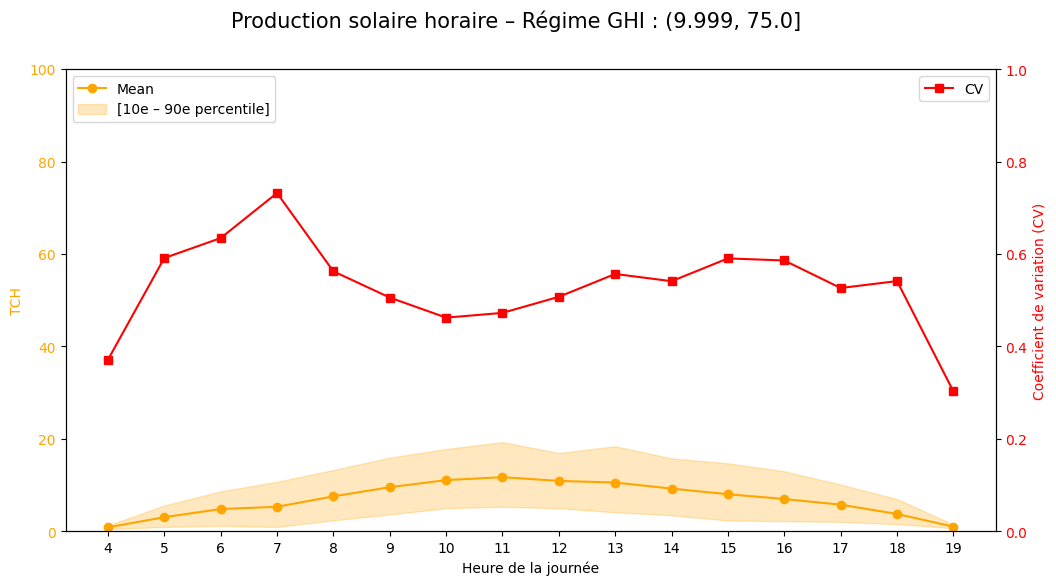

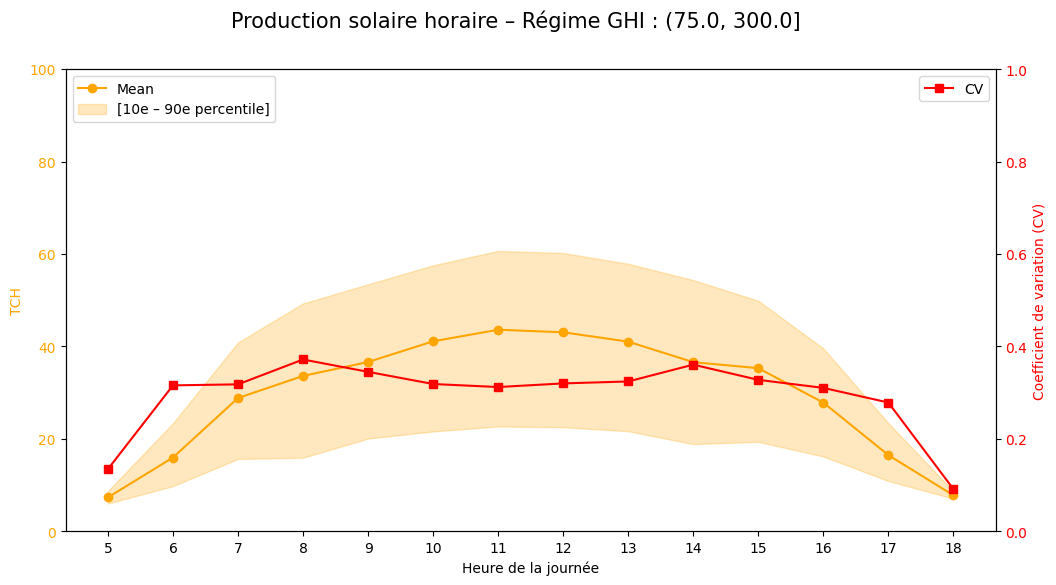

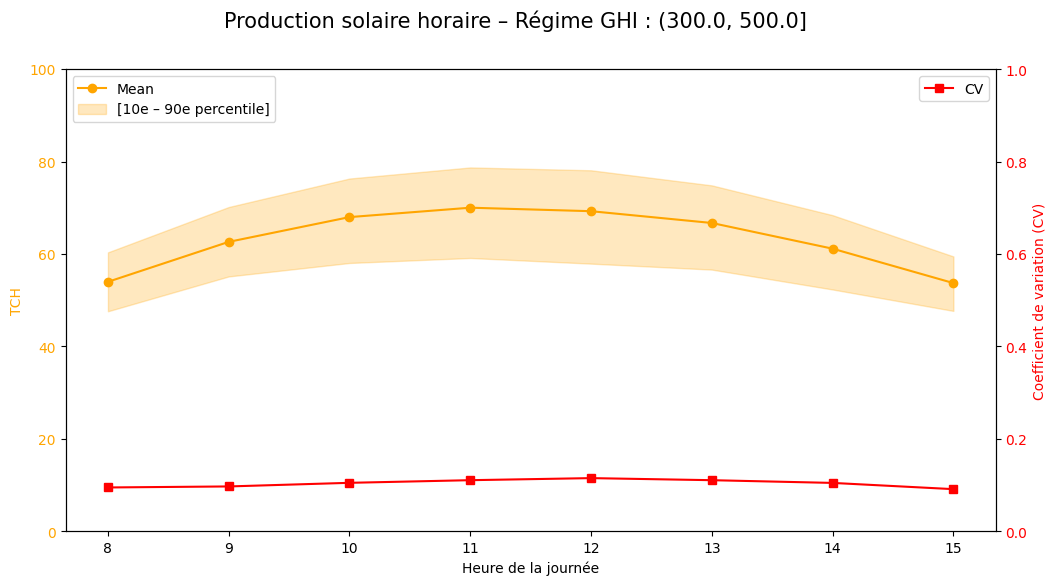

In [31]:
bins = [10, 75, 300, 500]

df_day['GHI_bin2'] = pd.cut(
    df_day['ghi_region'],
    bins=bins,
    include_lowest=True
)


for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):

    # Statistiques horaires
    hour_stats = df_bin.groupby('hour')['tch'].describe()
    hour_stats['cv'] = hour_stats['std'] / hour_stats['mean']

    # Percentiles
    hour_stats['p10'] = df_bin.groupby('hour')['tch'].quantile(0.10)
    hour_stats['p90'] = df_bin.groupby('hour')['tch'].quantile(0.90)
    # display(hour_stats)
    
    heures = hour_stats.index
    mean = hour_stats['mean']
    cv = hour_stats['cv']
    p10 = hour_stats['p10']
    p90 = hour_stats['p90']

    # Figure
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Moyenne + bande P10–P90
    ax1.plot(heures, mean, marker='o', color='orange', label='Mean')
    ax1.fill_between(heures, p10, p90, color='orange', alpha=0.25,
                     label='[10e – 90e percentile]')
    ax1.set_xlabel('Heure de la journée')
    ax1.set_ylabel('TCH', color='orange')
    ax1.tick_params(axis='y', labelcolor='orange')
    ax1.set_ylim(0, 100)
    ax1.set_xticks(heures)

    # Axe secondaire : CV
    ax2 = ax1.twinx()
    ax2.plot(heures, cv, marker='s', color='red', label='CV')
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('Coefficient de variation (CV)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Titre et légendes
    fig.suptitle(
        f'Production solaire horaire – Régime GHI : {ghi_bin}',
        fontsize=15
    )
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.show()


/tmp/ipykernel_26047/1929467577.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):


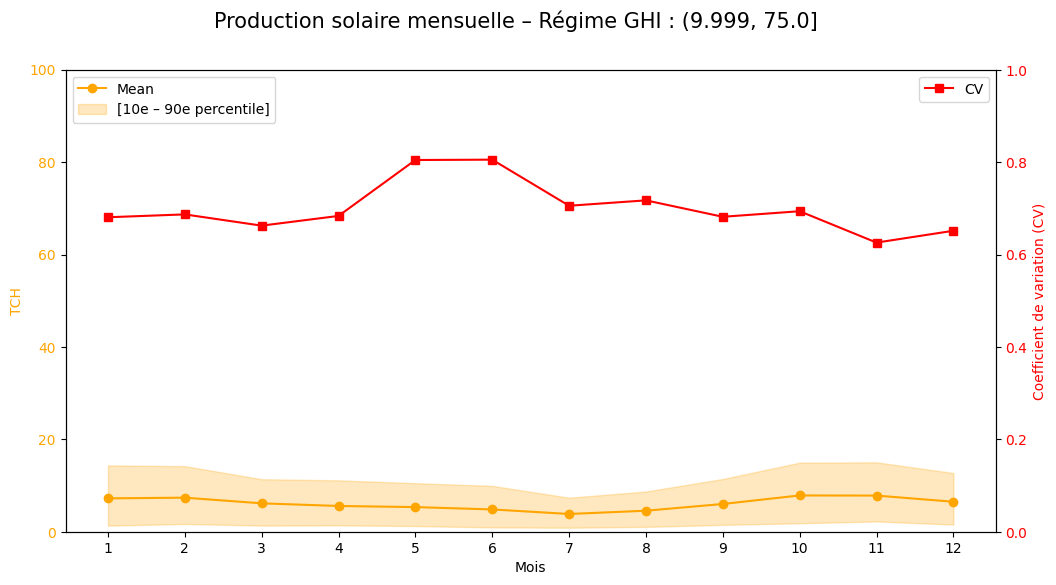

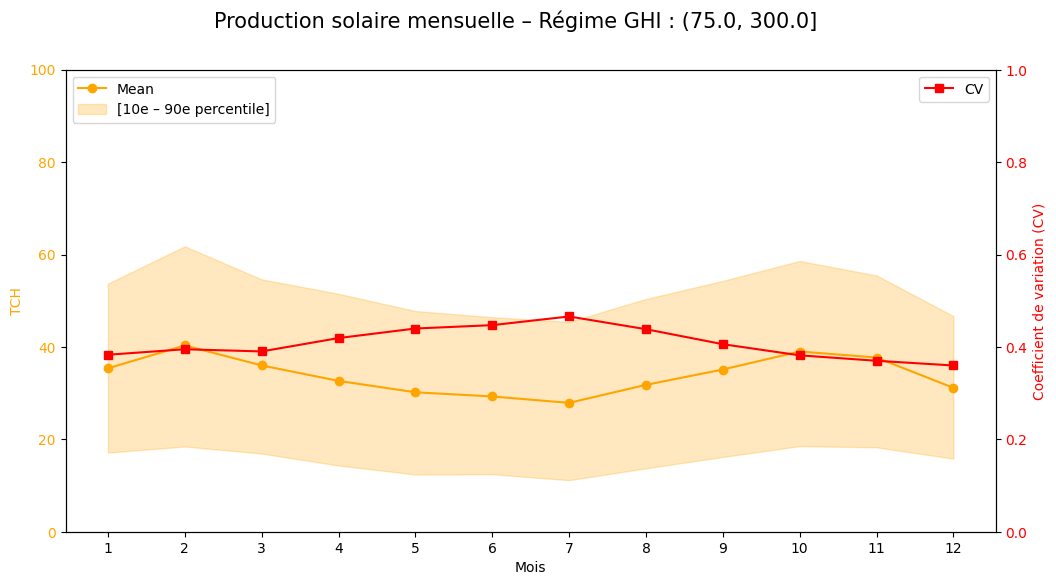

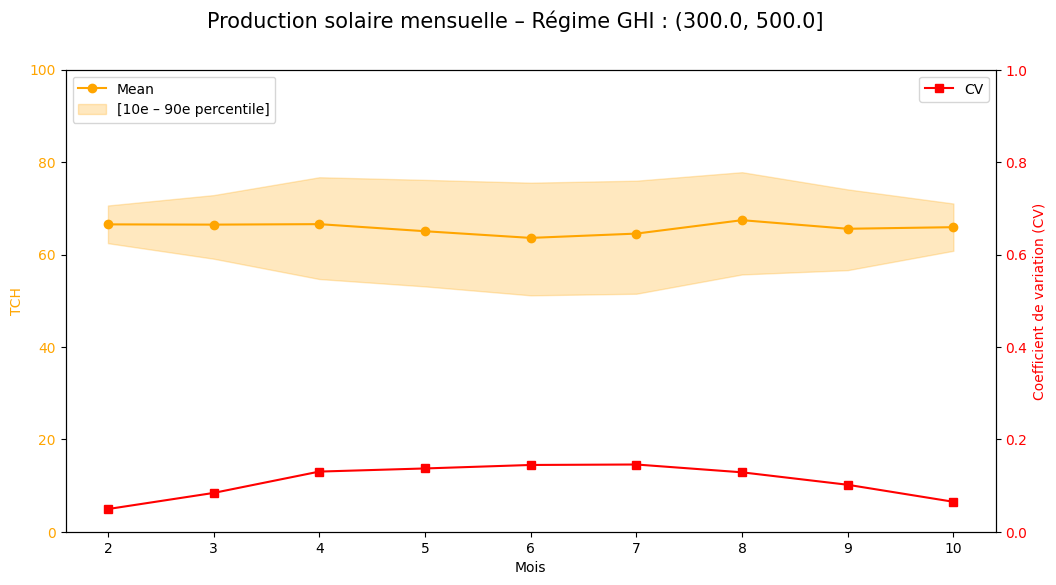

In [32]:
for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):

    # Statistiques horaires
    month_stats = df_bin.groupby('month')['tch'].describe()
    month_stats['cv'] = month_stats['std'] / month_stats['mean']

    # Percentiles
    month_stats['p10'] = df_bin.groupby('month')['tch'].quantile(0.10)
    month_stats['p90'] = df_bin.groupby('month')['tch'].quantile(0.90)

    mois = month_stats.index
    mean = month_stats['mean']
    cv = month_stats['cv']
    p10 = month_stats['p10']
    p90 = month_stats['p90']

    # Figure
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Moyenne + bande P10–P90
    ax1.plot(mois, mean, marker='o', color='orange', label='Mean')
    ax1.fill_between(mois, p10, p90, color='orange', alpha=0.25,
                     label='[10e – 90e percentile]')
    ax1.set_xlabel('Mois')
    ax1.set_ylabel('TCH', color='orange')
    ax1.tick_params(axis='y', labelcolor='orange')
    ax1.set_ylim(0, 100)
    ax1.set_xticks(mois)

    # Axe secondaire : CV
    ax2 = ax1.twinx()
    ax2.plot(mois, cv, marker='s', color='red', label='CV')
    ax2.set_ylim(0,1)
    ax2.set_ylabel('Coefficient de variation (CV)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Titre et légendes
    fig.suptitle(
        f'Production solaire mensuelle – Régime GHI : {ghi_bin}',
        fontsize=15
    )
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.show()


/tmp/ipykernel_26047/1486923468.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['doy'] = df_day['Date'].dt.dayofyear
/tmp/ipykernel_26047/1486923468.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):


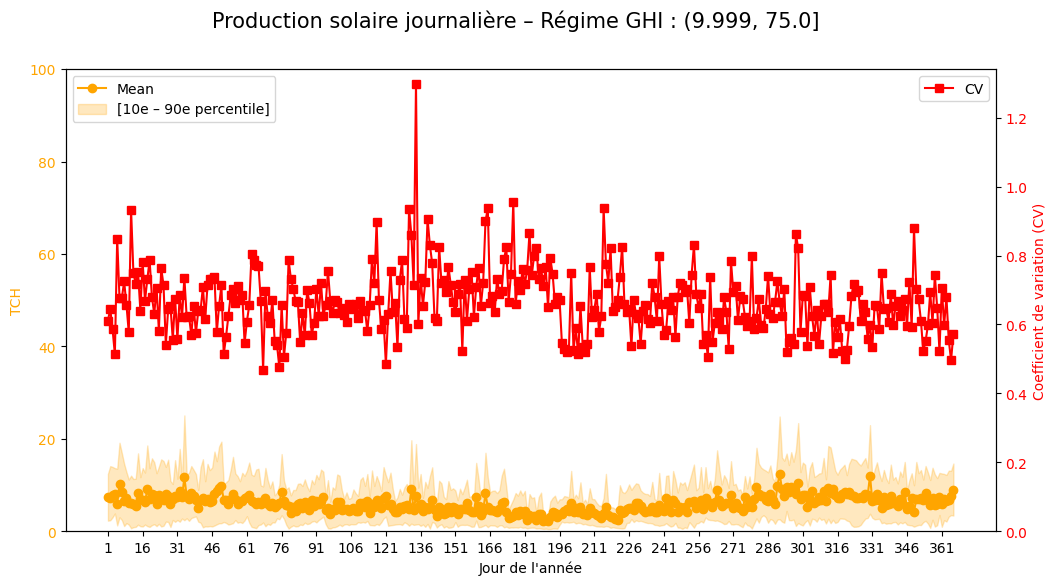

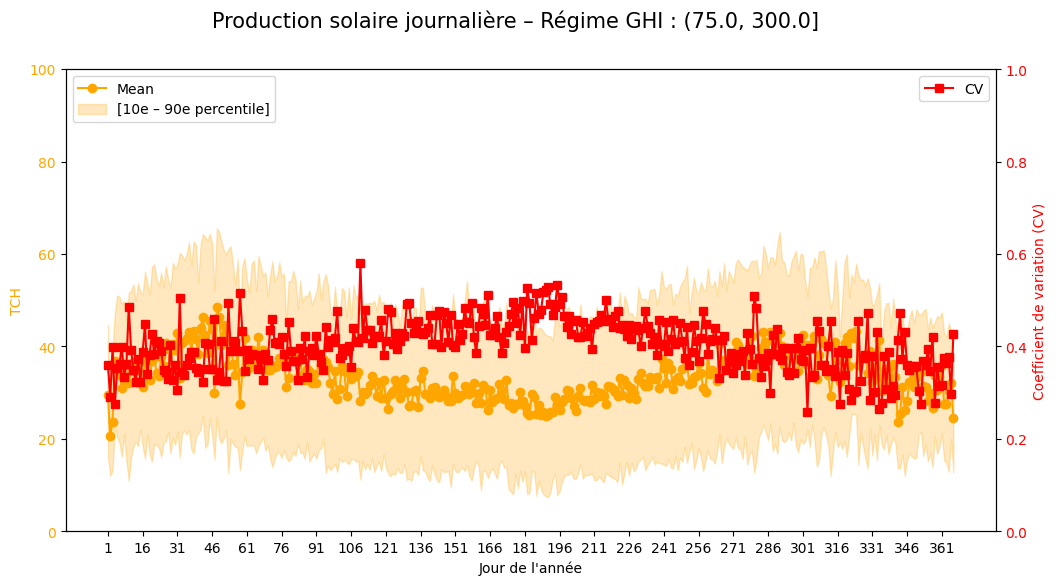

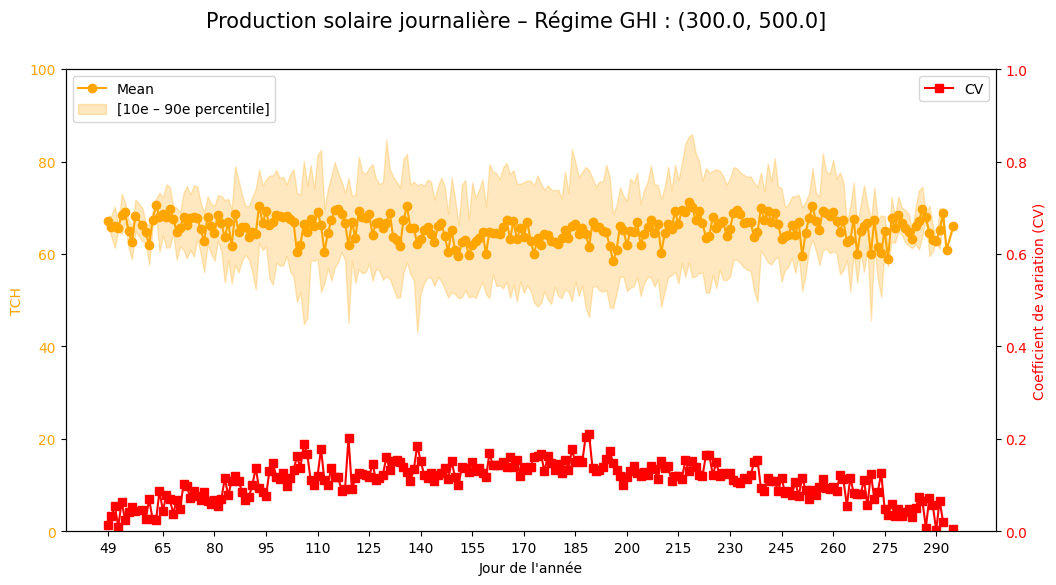

In [33]:
df_day['doy'] = df_day['Date'].dt.dayofyear
for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):

    # Statistiques horaires
    jour_stats = df_bin.groupby('doy')['tch'].describe()
    jour_stats['cv'] = jour_stats['std'] / jour_stats['mean']

    # Percentiles
    jour_stats['p10'] = df_bin.groupby('doy')['tch'].quantile(0.10)
    jour_stats['p90'] = df_bin.groupby('doy')['tch'].quantile(0.90)

    jours = jour_stats.index
    mean = jour_stats['mean']
    cv = jour_stats['cv']
    p10 = jour_stats['p10']
    p90 = jour_stats['p90']

    # Figure
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Moyenne + bande P10–P90
    ax1.plot(jours, mean, marker='o', color='orange', label='Mean')
    ax1.fill_between(jours, p10, p90, color='orange', alpha=0.25,
                     label='[10e – 90e percentile]')
    ax1.set_xlabel("Jour de l'année")
    ax1.set_ylabel('TCH', color='orange')
    ax1.tick_params(axis='y', labelcolor='orange')
    ax1.set_ylim(0, 100)
    ax1.set_xticks(jours[::15])

    # Axe secondaire : CV
    ax2 = ax1.twinx()
    ax2.plot(jours, cv, marker='s', color='red', label='CV')
    ax2.set_ylim(0, max(ax2.get_ylim()[1], 1))
    ax2.set_ylabel('Coefficient de variation (CV)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Titre et légendes
    fig.suptitle(
        f'Production solaire journalière – Régime GHI : {ghi_bin}',
        fontsize=15
    )
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.show()


## Conclusion : pourquoi le **GHI** porte l'essentiel de la variabilité

Les figures par **régime de GHI** montrent une lecture très claire :

- Quand le **GHI est faible** (journées nuageuses / diffus), la production **TCH** devient **plus instable** : la bande *P10–P90* s'élargit et le **CV** (variabilité relative) augmente.
- Quand le **GHI est élevé** (journées dégagées), la production est **plus régulière** : la dispersion se resserre et le **CV** diminue.

Autrement dit, **le GHI est la variable qui “déclenche” la variabilité** observée dans la production : il capte à la fois l'intensité du rayonnement reçu et, indirectement, l'état du ciel (clair vs couvert) qui gouverne la fluctuation.